# iPLA Calibrator Evaluation

This notebook evaluates NfL calibrators in the NfL-iPLA (immunosorbent Proximity Ligation Assay) platform.  
The key question is: which commercially available NfL calibrators produce a valid PCR standard curve and over what concentration range?

**Analysis overview:**
1. Import and pre-process calibrator assay data
2. Exploratory visualisation: Cq vs log₁₀(concentration) per calibrator
3. Define and apply a valid linear fit window based on PCR efficiency criteria
4. Assess all calibrators simultaneously using `plot_calibrator_fits()`
5. Final publication-quality figure using project colour conventions

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────
# ProxiPal is the project's custom analysis library (ProxiPal.py in repo root).
# It provides: robust_4pl_fit(), xlog10_4PL(), LoB/LoD/LoQ per CLSI EP17,
# Passing-Bablok, Bland-Altman, and helper utilities.
# Adding the parent directory to sys.path allows `from ProxiPal import *`
# regardless of the notebook's working directory.

import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ProxiPal also imports pandas, numpy, scipy, matplotlib — these are
# available after this line without separate import statements.
# See: https://github.com/jeffsmith8/NfL-iPLA-paper


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-05-18 16:47:03
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\iPLA Calibrator Selection
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\s

In [2]:
# ── Data import ───────────────────────────────────────────────────────────
# iPLA_cal.csv: one row per replicate measurement of a calibrator standard.
# Key columns:
#   sample_id             — calibrator identifier (e.g. 'std_1', 'std_2')
#   expt_folder_csv       — source experiment file (used as a batch identifier)
#   ct; mean              — mean Cq across qPCR technical replicates
#   py_known_conc         — nominal NfL concentration (pg/ml)
#   py_known_conc_log10   — log10 of the above (pre-computed for convenience)
#   SLR; log10(x); ...    — SLR-derived concentration estimate from ProxiPal
#   calibrator            — calibrator product identifier string

cal_df = pd.read_csv('iPLA_cal.csv')

# Preview: confirm expected columns and data shape
view_cols = ['sample_id', 'expt_folder_csv', 'ct; mean',
             'py_known_conc', 'py_known_conc_log10',
             'SLR; log10(x); exc_std0; ct; mean_ng/L', 'calibrator']
cal_df[view_cols].head(2)


,sample_id,expt_folder_csv,ct; mean,py_known_conc,py_known_conc_log10,SLR; log10(x); exc_std0; ct; mean_ng/L,calibrator
0,std1[0]_progen#62008,250813_e130_kruti_calP1,31.3145,0.0,NaN,0.0243,progen#62008
1,std1[5000]_progen#62008,250813_e130_kruti_calP1,12.8420,5000.0,3.69897,5487.7612,progen#62008


In [3]:
# ── Deduplication and filtering ───────────────────────────────────────────
# cal_df contains one row per replicate per standard curve point.
# For calibrator evaluation we work with mean Cq values (one row per
# unique sample × experiment × replicate group).
#
# drop_duplicates on ['expt_folder_csv', 'sample_id', 'rep_id', 'usr_mean_ng/L']
# retains the first occurrence of each unique combination, collapsing
# within-group technical replicates that have already been averaged.
#
# dropna on py_known_conc_log10 removes rows where the nominal concentration
# is unknown (e.g. blank wells, internal controls) — these cannot be
# placed on a standard curve.

cal_df_mean = cal_df.drop_duplicates(
    subset=['expt_folder_csv', 'sample_id', 'rep_id', 'usr_mean_ng/L']
)
cal_df_mean_f = cal_df_mean.dropna(subset=['py_known_conc_log10'])


## Exploratory visualisation: Cq vs concentration (log₁₀ scale)

This plot provides an initial overview of how mean Cq tracks with nominal NfL concentration for each calibrator. Cq is plotted on the y-axis (decreasing with increasing input — higher concentration → lower Cq). Concentration is shown on a log₁₀-transformed x-axis.

Two calibrators are excluded from regression line fitting (`Origene#TP305920`, `RnD#9715-NF-050`) due to poor or nonlinear Cq response across the dilution range — scatter points are still shown.

Two further calibrators (`abnova#H00004747-P01`, `PerkinElmer#AL3123S`) are restricted to the 1.6–5000 pg/ml range for regression fitting, as their Cq response is linear only within this window.

This is an exploratory cell using `sklearn.LinearRegression`; the formal efficiency-bounded analysis follows in subsequent cells.

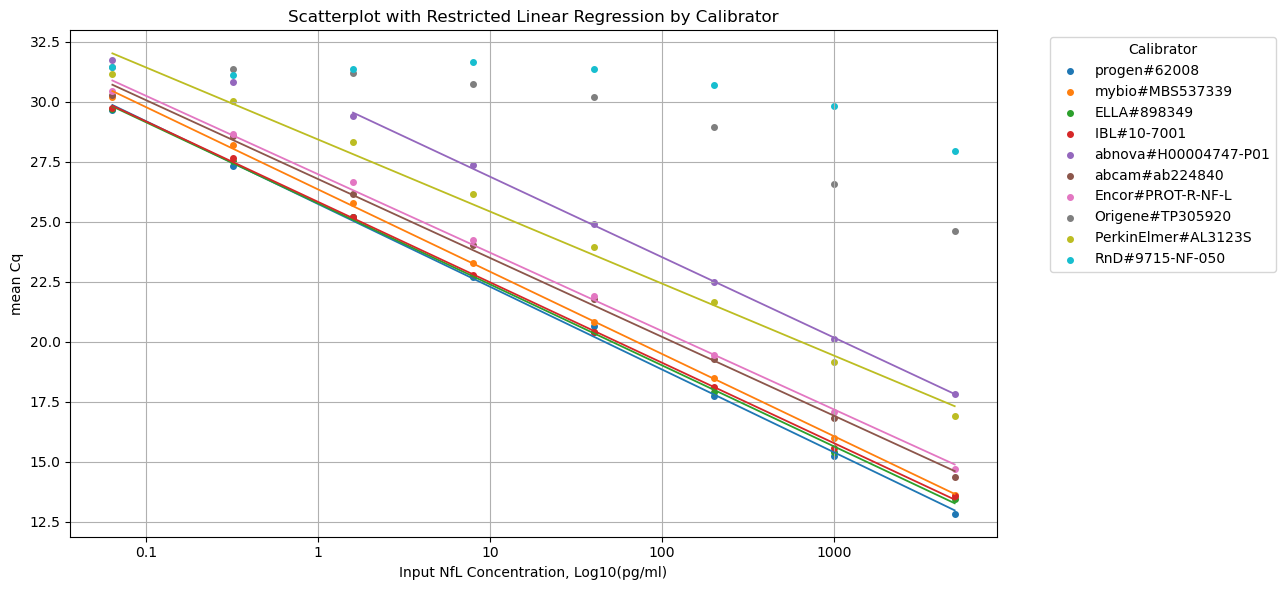

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Working copy of the filtered mean dataframe
df = cal_df_mean_f.copy()

# Assign a colour to each unique calibrator string using tab10
palette = sns.color_palette("tab10", n_colors=df['calibrator'].nunique())
calibrator_list = df['calibrator'].unique()
color_dict = dict(zip(calibrator_list, palette))

# Calibrators with no valid linear response — scatter only, no regression line
exclude_regression = ['Origene#TP305920', 'RnD#9715-NF-050']

# Calibrators whose linear range is empirically restricted to 1.6–5000 pg/ml
restricted_range_cals = ['abnova#H00004747-P01', 'PerkinElmer#AL3123S']
log_xmin, log_xmax = np.log10(1.6), np.log10(5000)

# Tick positions and labels for human-readable log10 x-axis
log_ticks = [np.log10(x) for x in [0.1, 1, 10, 100, 1000]]
log_labels = ['0.1', '1', '10', '100', '1000']

plt.figure(figsize=(13, 6))
for label in calibrator_list:
    group = df[df['calibrator'] == label]

    # All data points plotted regardless of fit eligibility
    plt.scatter(
        group['py_known_conc_log10'],
        group['ct; mean'],
        label=label,
        s=16,
        color=color_dict[label],
    )

    if label in exclude_regression:
        continue

    # Restrict fitting range for selected calibrators
    if label in restricted_range_cals:
        fit_data = group[
            (group['py_known_conc'] >= 1.6) & (group['py_known_conc'] <= 5000)
        ]
    else:
        fit_data = group

    # OLS linear regression in log10(conc) vs Cq space
    if len(fit_data) > 1:
        X = fit_data[['py_known_conc_log10']].values
        y = fit_data['ct; mean'].values
        model = LinearRegression().fit(X, y)

        if label in restricted_range_cals:
            x_range = np.linspace(log_xmin, log_xmax, 100).reshape(-1, 1)
        else:
            x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

        y_pred = model.predict(x_range)
        plt.plot(x_range, y_pred, color=color_dict[label], linewidth=1.3)

plt.xlabel('Input NfL Concentration, Log10(pg/ml)')
plt.ylabel('mean Cq')
plt.title('Scatterplot with Restricted Linear Regression by Calibrator')
plt.xticks(ticks=log_ticks, labels=log_labels)
plt.legend(title='Calibrator', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## “Defining Valid Standard Curve Windows in qPCR-PLA”
qPCR standard curve performance can be evaluated in two complementary ways. One approach identifies the most PCR-like region of the dilution series, maximising linearity (R²) within the theoretical 95–105% efficiency bounds; this highlights where the assay behaves closest to ideal amplification. The other approach identifies the largest possible portion of the curve that still meets the 95–105% efficiency requirement, prioritising breadth of coverage over perfect fit. Together, these methods provide both a measure of where PCR works best and how much of the curve can be trusted, offering a robust framework for defining valid calibration ranges in PLA development.
  
   
### 🔵 `find_max_points_linear_fit_window()`

**Goal:**  
Find the largest possible portion of the curve that is still PCR-valid.

**Selection criteria:**  
- Maximises number of points included in the fit.  
- Slope must be within 95–105% efficiency bounds.  
- If ties occur, higher R² breaks the tie.  

**Trade-off:**  
- May accept a fit that is less “perfect” than the best-fit window, but includes more of the curve.  
- Prioritises *data coverage* over fit quality.  

**Best use case:**  
Defining calibrators and usable quantitation range in a validated assay → ensures results fall within a broad, PCR-like standard curve.  

---
### 🔴 `find_best_linear_fit_window()`

**Goal:**  
Find the most PCR-like region of the dilution series.

**Selection criteria:**  
- Maximises R² (best linearity).  
- Must fall within 95–105% efficiency bounds.  

**Trade-off:**  
- May select only a small window of data points if that gives the cleanest slope.  
- Prioritises *fit quality* over data coverage.  

**Best use case:**  
Early assay optimisation → to identify the dilution range that behaves closest to ideal PCR.  

---

👉 **Together:**  
- *Best-fit window* → tells you **where PCR works best**.  
- *Max-points window* → tells you **how much of the curve you can trust**.  


## Defining the acceptable linear range  
🔵 `find_max_points_linear_fit_window()`  
  
Accurate interpretation of qPCR standard curves requires that dilutional responses reflect genuine template amplification rather than assay noise, sample interferences, or other artefacts. A widely accepted benchmark is that PCR efficiency should fall between 95–105%, corresponding to slopes of −3.448 to −3.207 in Ct versus log10(dilution) space. Outside this range, deviations cannot be reliably distinguished from poor optimisation, stochastic amplification effects, or non-specific signal. This challenge is further amplified in proximity ligation assays (PLA), where the sigmoidal behaviour inherent to ligand binding can mask or mimic true deviations in PCR performance. To address this, we implemented a systematic regression-based approach that tests all possible subsets of standard curve data and identifies the largest contiguous dilution range that produces a slope within the theoretical 95–105% efficiency bounds. This method, which we term find_max_points_linear_fit_window(), provides an objective basis for defining the range of calibrators that behave as a bona fide PCR standard curve. By applying this analysis to candidate calibrators, we could directly assess which reagents supported valid dilutional linearity and therefore establish a defensible quantitation range for PLA development.  
  

In [5]:
def find_max_points_linear_fit_window(x, y, slope_bounds=(-3.448, -3.207),
                                      r2_thresh=0.99, plot=True, show_all_fits=False):
    """
    Identify the best linear fit window that accommodates the most empirical points
    while keeping slope within bounds and R² above threshold.
    """

    x = np.array(x); y = np.array(y)
    best_window = None
    best_size = -np.inf
    best_r2 = -np.inf
    all_valid_fits = []

    n = len(x)
    from itertools import combinations
    from scipy.stats import linregress

    for window_size in range(2, n + 1):   # no strict min_points unless you want one
        for indices in combinations(range(n), window_size):
            x_sub, y_sub = x[list(indices)], y[list(indices)]
            if len(np.unique(x_sub)) < 2:
                continue

            slope, intercept, r_value, _, _ = linregress(x_sub, y_sub)
            r2 = r_value**2
            efficiency = 10**(-1 / slope) - 1

            if slope_bounds[0] <= slope <= slope_bounds[1] and r2 >= r2_thresh:
                all_valid_fits.append((slope, intercept, x_sub))
                if (len(indices) > best_size) or (len(indices) == best_size and r2 > best_r2):
                    best_window = {
                        'x1': min(x_sub), 'x2': max(x_sub),
                        'y1': slope * min(x_sub) + intercept,
                        'y2': slope * max(x_sub) + intercept,
                        'slope': slope, 'intercept': intercept,
                        'r2': r2, 'efficiency': efficiency,
                        'indices': indices
                    }
                    best_size = len(indices); best_r2 = r2

    if plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(6, 4))

        # Grey fits (optional)
        if show_all_fits:
            for slope, intercept, x_sub in all_valid_fits:
                xs = np.array([min(x_sub), max(x_sub)])
                ys = slope * xs + intercept
                ax.plot(xs, ys, color='grey', alpha=0.15, linewidth=1)

        # Highlight best fit
        if best_window:
            x1, x2, y1, y2 = best_window['x1'], best_window['x2'], best_window['y1'], best_window['y2']
            ax.plot([x1, x2], [y1, y2], color='red', linewidth=1, label='Best linear fit')
            ax.scatter([x1, x2], [y1, y2], color='red', marker='x', s=80, linewidths=1)
            used_idx = set(best_window['indices'])
            for i, (xi, yi) in enumerate(zip(x, y)):
                if i in used_idx: ax.scatter(xi, yi, color='black', zorder=6)
                else: ax.scatter(xi, yi, facecolors='none', edgecolors='black', zorder=6)

        ax.set_xlabel('log10(inv_dilution)')
        ax.set_ylabel('Ct')
        ax.set_title('Best Linear Fit Window (max points)')
        ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

    if best_window:
        print(f"Best fit uses {len(best_window['indices'])} points")
        print(f"Slope: {best_window['slope']:.4f}, R²: {best_window['r2']:.4f}, "
              f"Efficiency: {(best_window['efficiency'])*100:.2f}%")

    return best_window


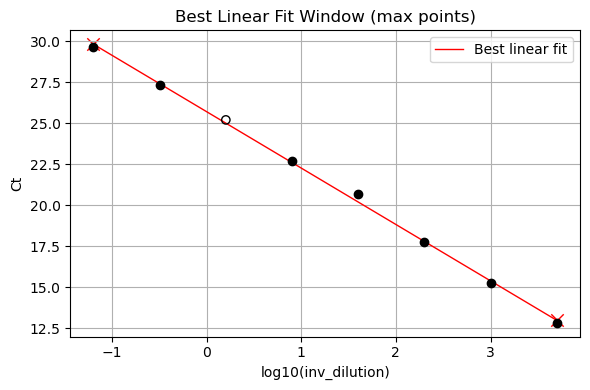

Best fit uses 7 points
Slope: -3.4397, R²: 0.9986, Efficiency: 95.31%


In [6]:
# ── Per-calibrator inspection: Progen ─────────────────────────────────
# Extracts Cq and log10(concentration) values for Progen only,
# then calls find_max_points_linear_fit_window() to identify the
# largest contiguous dilution range with a slope within 95–105% PCR efficiency.
# Open circles in the output plot = points excluded from the best-fit window.

x = cal_df_mean_f[cal_df_mean_f['calibrator']=='progen#62008']['py_known_conc_log10'].values
y = cal_df_mean_f[cal_df_mean_f['calibrator']=='progen#62008']['ct; mean'].values

max_points_linear_fit_window = find_max_points_linear_fit_window(
    x, y,
    slope_bounds=(-3.448, -3.207),
    r2_thresh=0.99,
    plot=True,
    show_all_fits=False
)


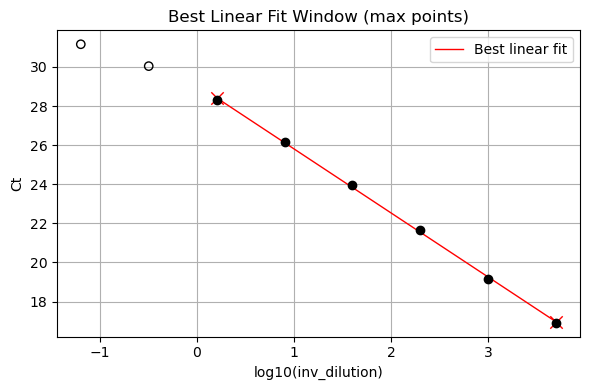

Best fit uses 6 points
Slope: -3.2796, R²: 0.9995, Efficiency: 101.80%


In [7]:
# ── Per-calibrator inspection: PerkinElmer ─────────────────────────────────
# Extracts Cq and log10(concentration) values for PerkinElmer only,
# then calls find_max_points_linear_fit_window() to identify the
# largest contiguous dilution range with a slope within 95–105% PCR efficiency.
# Open circles in the output plot = points excluded from the best-fit window.

x = cal_df_mean_f[cal_df_mean_f['calibrator']=='PerkinElmer#AL3123S ']['py_known_conc_log10'].values
y = cal_df_mean_f[cal_df_mean_f['calibrator']=='PerkinElmer#AL3123S ']['ct; mean'].values

max_points_linear_fit_window = find_max_points_linear_fit_window(
    x, y,
    slope_bounds=(-3.448, -3.207),
    r2_thresh=0.99,
    plot=True,
    show_all_fits=False
)


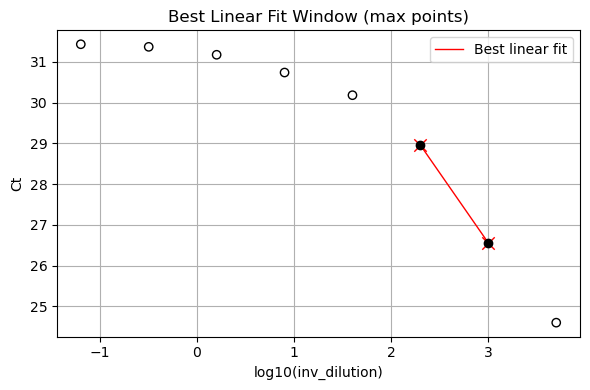

Best fit uses 2 points
Slope: -3.4336, R²: 1.0000, Efficiency: 95.54%


In [8]:
# ── Per-calibrator inspection: Origene ─────────────────────────────────
# Extracts Cq and log10(concentration) values for Origene only,
# then calls find_max_points_linear_fit_window() to identify the
# largest contiguous dilution range with a slope within 95–105% PCR efficiency.
# Open circles in the output plot = points excluded from the best-fit window.

x = cal_df_mean_f[cal_df_mean_f['calibrator']=='Origene#TP305920']['py_known_conc_log10'].values
y = cal_df_mean_f[cal_df_mean_f['calibrator']=='Origene#TP305920']['ct; mean'].values

max_points_linear_fit_window = find_max_points_linear_fit_window(
    x, y,
    slope_bounds=(-3.448, -3.207),
    r2_thresh=0.99,
    plot=True,
    show_all_fits=False
)


## Assess all calibrators at once

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

def plot_calibrator_fits(df, slope_bounds=(-3.448, -3.207), r2_thresh=0.99,
                         figsize=(7, 5), legend_fontsize=9, cmap_name="tab10"):
    """
    Apply find_max_points_linear_fit_window() to each calibrator in the dataframe,
    plot all best fits on the same axes, and return fit statistics.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'calibrator', 'py_known_conc_log10', 'ct; mean'
    slope_bounds : tuple
        Efficiency slope bounds (default: -3.448 to -3.207, i.e. 95–105% efficiency)
    r2_thresh : float
        Minimum R² threshold
    figsize : tuple
        Size of the figure (width, height)
    legend_fontsize : int
        Font size for the legend text
    cmap_name : str
        Name of matplotlib colormap (default: "tab10")

    Returns
    -------
    results_df : pd.DataFrame
        Table of best-fit statistics for each calibrator
    fig, ax : matplotlib Figure and Axes
        The plot object (can be saved or further modified)
    """
    fig, ax = plt.subplots(figsize=figsize)

    calibrators = df['calibrator'].unique()
    cmap = mpl.colormaps[cmap_name]
    colors = [cmap(i) for i in range(len(calibrators))]

    results = []

    for idx, (calibrator, sub) in enumerate(df.groupby("calibrator")):
        x = sub['py_known_conc_log10'].values
        y = sub['ct; mean'].values

        best = find_max_points_linear_fit_window(
            x, y,
            slope_bounds=slope_bounds,
            r2_thresh=r2_thresh,
            plot=False
        )

        if best:
            color = colors[idx]

            # Draw best fit line
            ax.plot([best['x1'], best['x2']],
                    [best['y1'], best['y2']],
                    color=color,
                    linewidth=1,
                    label=f"{calibrator} ({best['efficiency']*100:.1f}%)")

            # Draw calibrator points in same hue
            used_idx = set(best['indices'])
            for i, (xi, yi) in enumerate(zip(x, y)):
                if i in used_idx:
                    ax.scatter(xi, yi, color=color, s=20)
                else:
                    ax.scatter(xi, yi, facecolors='none', edgecolors=color, s=20)

            # Store results
            results.append({
                "calibrator": calibrator,
                "slope": best['slope'],
                "intercept": best['intercept'],
                "r2": best['r2'],
                "efficiency": (best['efficiency'])*100,  # as %
                "points_used": len(best['indices'])
            })

    # Axis labels
    ax.set_xlabel("Input concentration (pg/ml)")
    ax.set_ylabel("Cq")
#     ax.set_title("Max Points Fit Across Calibrators")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=legend_fontsize)

    # Replace log10 ticks with linear concentration labels in normal decimal notation
    xticks = ax.get_xticks()
    ax.set_xticklabels([f"{10**tick:.0f}" for tick in xticks])

    plt.tight_layout()

    results_df = pd.DataFrame(results)
    return results_df, fig, ax


Best fit uses 8 points
Slope: -3.3774, R²: 0.9995, Efficiency: 97.74%
Best fit uses 8 points
Slope: -3.2678, R²: 0.9982, Efficiency: 102.31%
Best fit uses 8 points
Slope: -3.3523, R²: 0.9996, Efficiency: 98.75%
Best fit uses 2 points
Slope: -3.4336, R²: 1.0000, Efficiency: 95.54%
Best fit uses 6 points
Slope: -3.2796, R²: 0.9995, Efficiency: 101.80%
Best fit uses 8 points
Slope: -3.2881, R²: 0.9981, Efficiency: 101.43%
Best fit uses 6 points
Slope: -3.3529, R²: 0.9994, Efficiency: 98.73%
Best fit uses 8 points
Slope: -3.4290, R²: 0.9996, Efficiency: 95.72%
Best fit uses 7 points
Slope: -3.4397, R²: 0.9986, Efficiency: 95.31%


C:\Users\smith.j\AppData\Local\Temp\ipykernel_31204\3883309642.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**tick:.0f}" for tick in xticks])


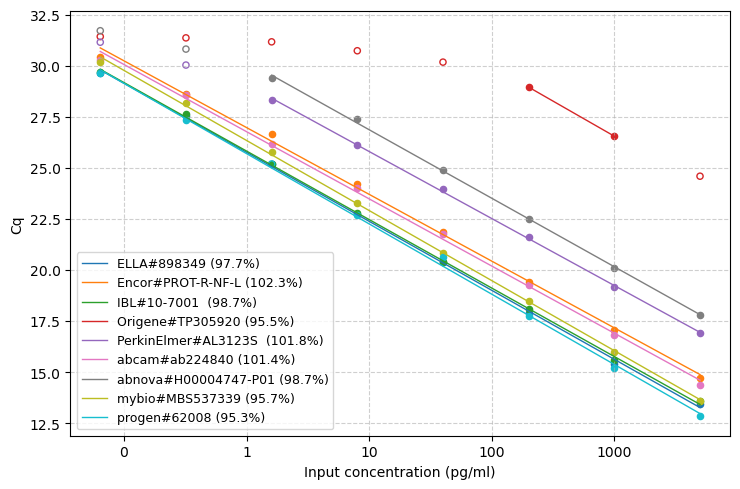

In [10]:
results_df, fig, ax  = plot_calibrator_fits(cal_df_mean_f, slope_bounds=(-3.448, -3.207), 
                                            r2_thresh=0.99, 
                                            figsize=(7.5, 5), legend_fontsize=9)


---
## Publication plot

The cell below reproduces the `plot_calibrator_fits()` analysis using the project-wide colour conventions and formatting.  

**Colour mapping** follows `calibrator_colours` defined in the session context:  
`Uman` → black, `Progen` → vermillion, `R&D` → reddish purple, `PerkinElmer` → bluish green, `Origene` → orange, `Abcam` → blue, `MyBio` → sky blue, `Ella` → yellow.  
`Encor` and `Abnova` share colours with `Origene` and `MyBio` respectively and are rendered with a dashed linestyle.

The calibrator label strings in `cal_df_mean_f` use vendor-catalogue identifiers (e.g. `progen#62008`).  
The mapping below translates these to the short project names used in all figures.

**Figure spec:** single-column width (88 mm), 6 pt Helvetica/Arial throughout, exported as SVG at 300 DPI.

In [17]:
# ── Project-wide colour conventions (Nat Comms / Okabe-Ito) ──────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Nat Comms figure formatting — applied globally for all subsequent plots
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.rcParams['font.size'] = 6
plt.rcParams['axes.titlesize'] = 6
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['scatter.edgecolors'] = 'none'

okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

# Project-wide calibrator colour map — applied consistently across all figures
calibrator_colours = {
    'Uman':        okabe_ito['black'],
    'Progen':      okabe_ito['vermillion'],
    'R&D':         okabe_ito['reddish purple'],
    'PerkinElmer': okabe_ito['bluish green'],
    'Origene':     okabe_ito['orange'],
    'Abcam':       okabe_ito['blue'],
    'MyBio':       okabe_ito['sky blue'],
    'Ella':        okabe_ito['yellow'],
    'Encor':       okabe_ito['orange'],    # shares colour with Origene → dashed line
    'Abnova':      okabe_ito['sky blue'],  # shares colour with MyBio  → dashed line
}

def get_style(calibrator):
    """Return (colour_hex, linestyle) for a calibrator.
    Calibrators sharing a colour are distinguished by linestyle (solid vs dashed).
    """
    colour = calibrator_colours[calibrator]
    sharing = [k for k, v in calibrator_colours.items() if v == colour]
    if len(sharing) > 1 and sharing.index(calibrator) > 0:
        return colour, '--'
    return colour, '-'

# ── Catalogue ID → project short-name mapping ─────────────────────────────
# The raw data uses vendor catalogue strings; these must be mapped to the
# canonical project names used in calibrator_colours.
# Add entries here if new calibrators are introduced.
calibrator_name_map = {
    'progen#62008':              'Progen',
    'mybio#MBS537339':           'MyBio',
    'ELLA#898349':               'Ella',
    'IBL#10-7001 ':              'Uman',        # note trailing space in raw data
    'abnova#H00004747-P01':      'Abnova',
    'abcam#ab224840':            'Abcam',
    'Encor#PROT-R-NF-L':         'Encor',
    'Origene#TP305920':          'Origene',
    'PerkinElmer#AL3123S ':      'PerkinElmer', # note trailing space in raw data
    'RnD#9715-NF-050':           'R&D',
}

print('Unique calibrator strings in data:')
print(sorted(cal_df_mean_f['calibrator'].unique()))


Unique calibrator strings in data:
['ELLA#898349', 'Encor#PROT-R-NF-L', 'IBL#10-7001 ', 'Origene#TP305920', 'PerkinElmer#AL3123S ', 'RnD#9715-NF-050', 'abcam#ab224840', 'abnova#H00004747-P01', 'mybio#MBS537339', 'progen#62008']


In [18]:
# ── Remap calibrator labels and filter to mapped entries only ─────────────
# Creates a working copy with a 'calibrator_short' column containing the
# canonical project name. Rows whose catalogue string has no entry in
# calibrator_name_map are excluded — update the map above to include them.

cal_pub = cal_df_mean_f.copy()
cal_pub['calibrator_short'] = cal_pub['calibrator'].map(calibrator_name_map)

unmapped = cal_pub[cal_pub['calibrator_short'].isna()]['calibrator'].unique()
if len(unmapped):
    print(f'WARNING: {len(unmapped)} calibrator string(s) not in name map — excluded:')
    for u in unmapped:
        print(f'  {repr(u)}')

cal_pub = cal_pub.dropna(subset=['calibrator_short'])

# Replace the catalogue string column so plot_calibrator_fits() receives
# clean short names directly
cal_pub_plot = cal_pub.copy()
cal_pub_plot['calibrator'] = cal_pub_plot['calibrator_short']

print(f'Calibrators in publication dataset: {sorted(cal_pub_plot["calibrator"].unique())}')


Calibrators in publication dataset: ['Abcam', 'Abnova', 'Ella', 'Encor', 'MyBio', 'Origene', 'PerkinElmer', 'Progen', 'R&D', 'Uman']


Best fit uses 8 points
Slope: -3.2881, R²: 0.9981, Efficiency: 101.43%
Best fit uses 6 points
Slope: -3.3529, R²: 0.9994, Efficiency: 98.73%
Best fit uses 8 points
Slope: -3.3774, R²: 0.9995, Efficiency: 97.74%
Best fit uses 8 points
Slope: -3.2678, R²: 0.9982, Efficiency: 102.31%
Best fit uses 8 points
Slope: -3.4290, R²: 0.9996, Efficiency: 95.72%
Best fit uses 2 points
Slope: -3.4336, R²: 1.0000, Efficiency: 95.54%
Best fit uses 6 points
Slope: -3.2796, R²: 0.9995, Efficiency: 101.80%
Best fit uses 7 points
Slope: -3.4397, R²: 0.9986, Efficiency: 95.31%
R&D: no valid window found
Best fit uses 8 points
Slope: -3.3523, R²: 0.9996, Efficiency: 98.75%


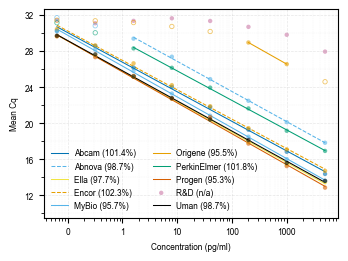

In [32]:
# ── Publication figure: max-points linear fit across all calibrators ──────
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(88/25.4, 66/25.4))

results = []

for calibrator in sorted(cal_pub_plot['calibrator'].unique()):
    sub = cal_pub_plot[cal_pub_plot['calibrator'] == calibrator]
    x = sub['py_known_conc_log10'].values
    y = sub['ct; mean'].values

    if calibrator not in calibrator_colours:
        print(f'Skipping {calibrator}: not in calibrator_colours')
        continue

    colour, linestyle = get_style(calibrator)

    best = find_max_points_linear_fit_window(
        x, y,
        slope_bounds=(-3.448, -3.207),
        r2_thresh=0.99,
        plot=False
    )

    if best is None:
        print(f'{calibrator}: no valid window found')
        ax.scatter(10**x, y, s=10, alpha=0.6, facecolor=colour,
                   edgecolors='none', label=f'{calibrator} (n/a)')
        continue

    used_idx = set(best['indices'])

    for i, (xi, yi) in enumerate(zip(x, y)):
        if i in used_idx:
            ax.scatter(10**xi, yi, s=10, alpha=0.6,
                       facecolor=colour, edgecolors='none', zorder=5)
        else:
            ax.scatter(10**xi, yi, s=10, alpha=0.6,
                       facecolor='none', edgecolors=colour,
                       linewidths=0.6, zorder=5)

    eff = best['efficiency'] * 100
    x_line = np.linspace(best['x1'], best['x2'], 200)
    y_line = best['slope'] * x_line + best['intercept']
    ax.plot(10**x_line, y_line,
            color=colour, linewidth=0.75, linestyle=linestyle,
            label=f'{calibrator} ({eff:.1f}%)')

    results.append({
        'calibrator':   calibrator,
        'slope':        round(best['slope'], 4),
        'intercept':    round(best['intercept'], 4),
        'r2':           round(best['r2'], 4),
        'efficiency_%': round(eff, 1),
        'points_used':  len(best['indices']),
    })

ax.set_xscale('log')
ax.set_xlabel('Concentration (pg/ml)')
ax.set_ylabel('Mean Cq')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.legend(frameon=False, ncols=2, loc='lower left')
ax.set_ylim(bottom=9.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(4))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))
ax.tick_params(axis='y', which='minor', length=2)
ax.grid(True, which='minor', linestyle='--', alpha=0.15, linewidth=0.3)
plt.tight_layout()
plt.savefig('fig_calibrator_linear_fit.svg', dpi=300, bbox_inches='tight')
plt.show()

### Best-fit statistics per calibrator

The table below summarises the `find_max_points_linear_fit_window()` output for each calibrator:  
- **slope** — linear regression slope in Cq vs log₁₀(pg/ml) space; PCR efficiency is derived as 10^(−1/slope) − 1  
- **efficiency_%** — PCR amplification efficiency within the valid window (target: 95–105%)  
- **r²** — linearity within the selected window (threshold: ≥ 0.99)  
- **points_used** — number of calibrator dilutions falling within the valid window

In [20]:
results_df = pd.DataFrame(results)
results_df


,calibrator,slope,intercept,r2,efficiency_%,points_used
0,Abcam,-3.2881,26.7789,0.9981,101.4,8
1,Abnova,-3.3529,30.2272,0.9994,98.7,6
2,Ella,-3.3774,25.7692,0.9995,97.7,8
3,Encor,-3.2678,26.9794,0.9982,102.3,8
4,MyBio,-3.4290,26.3485,0.9996,95.7,8
5,Origene,-3.4336,36.8599,1.0000,95.5,2
6,PerkinElmer,-3.2796,29.0874,0.9995,101.8,6
7,Progen,-3.4397,25.7047,0.9986,95.3,7
8,Uman,-3.3523,25.8297,0.9996,98.7,8
